Tracy, P. J., Kasper, J. C., Zurbuchen, T. H., Raines, J. M., Shearer, P., & Gilbert, J. (2015). THERMALIZATION OF HEAVY IONS IN THE SOLAR WIND. The Astrophysical Journal, 812(2), 170. https://doi.org/10.1088/0004-637X/812/2/170

In [1]:
from datetime import datetime,timedelta
from cdasws import CdasWs
cdas = CdasWs()

from astropy import units as u
u.set_enabled_aliases({'sec': u.s, '#': u.dimensionless_unscaled})

import spcphys_common_functions as scf
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from scipy.constants import physical_constants

In [2]:
TIME_RANGE = [datetime(1998, 2, 4), datetime(2011, 8, 22)]

_, proton_data = cdas.get_data(dataset='AC_H2_SWE', variables=['Np', 'Vp', 'Tpr'], time0=TIME_RANGE[0], time1=TIME_RANGE[1])
_, heavy_ion_data = cdas.get_data(dataset='AC_H3_SWI', variables=['nHe2', 'vHe2', 'vthHe2', 'HetoO', 'vO6', 'vthO6'], time0=TIME_RANGE[0], time1=TIME_RANGE[1])

In [3]:
_, heavy_ion_data = cdas.get_data(dataset='AC_H3_SWI', variables=['nHe2', 'vHe2', 'vthHe2', 'HetoO', 'vO6', 'vthO6'], time0=TIME_RANGE[0], time1=TIME_RANGE[1])

In [4]:
proton_time = proton_data['Epoch'].values
heavy_ion_time = heavy_ion_data['Epoch'].values

df_proton = pd.DataFrame({
    'time_proton': proton_time,
    'Np': proton_data['Np'].values,
    'Vp': proton_data['Vp'].values,
    'Tpr': proton_data['Tpr'].values,
    'vthpr': scf.vth_E_T.T_to_vth(proton_data['Tpr'].values * u.K, n=1).to(u.km / u.s).value
}).dropna().sort_values('time_proton').reset_index(drop=True)

df_heavy = pd.DataFrame({
    'time_heavy': heavy_ion_time,
    'nHe2': heavy_ion_data['nHe2'].values,
    'vHe2': heavy_ion_data['vHe2'].values,
    'THe2': scf.vth_E_T.vth_to_T(heavy_ion_data['vthHe2'].values * u.km / u.s, n=1).to(u.K).value,
    'vthHe2': heavy_ion_data['vthHe2'].values,
    'nO6': heavy_ion_data['nHe2'].values / heavy_ion_data['HetoO'].values,
    'vO6': heavy_ion_data['vO6'].values,
    'T_O6': scf.vth_E_T.vth_to_T(heavy_ion_data['vthO6'].values * u.km / u.s, n=1).to(u.K).value,
    'vthO6': heavy_ion_data['vthO6'].values
}).dropna().sort_values('time_heavy').reset_index(drop=True)

df_merged = pd.merge_asof(
    df_proton, df_heavy,
    left_on='time_proton', right_on='time_heavy',
    tolerance=pd.Timedelta('10min'),
    direction='nearest'
).dropna(subset=['time_heavy'])

df_matched = df_merged[['time_proton', 'time_heavy', 'Np', 'Vp', 'Tpr', 'vthpr', 'nHe2', 'vHe2', 'THe2', 'vthHe2', 'nO6', 'vO6', 'T_O6', 'vthO6']].copy()
df_matched['time_diff'] = (df_matched['time_proton'] - df_matched['time_heavy']).abs()
df_matched = df_matched.rename(columns={'time_proton': 'time'})

In [8]:
species_p = scf.coulomb_collision.SpeciesParamsTracy(
    charge=physical_constants['elementary charge'][0] * u.C,
    mass=physical_constants['proton mass'][0] * u.kg,
    n=df_matched['Np'].values * u.cm**-3,
    T=df_matched['Tpr'].values * u.K,
    v=df_matched['Vp'].values * u.km / u.s,
    distance=1 * u.au
)

species_a = scf.coulomb_collision.SpeciesParamsTracy(
    charge=2 * physical_constants['elementary charge'][0] * u.C,
    mass=physical_constants['alpha particle mass'][0] * u.kg,
    n=df_matched['nHe2'].values * u.cm**-3,
    T=df_matched['THe2'].values * u.K,
    v=df_matched['vHe2'].values * u.km / u.s,
    distance=1 * u.au
)

species_O6 = scf.coulomb_collision.SpeciesParamsTracy(
    charge=6 * physical_constants['elementary charge'][0] * u.C,
    mass=16 * physical_constants['atomic mass constant'][0] * u.kg,
    n=df_matched['nO6'].values * u.cm**-3,
    T=df_matched['T_O6'].values * u.K,
    v=df_matched['vO6'].values * u.km / u.s,
    distance=1 * u.au
)

In [14]:
AcHe2 = scf.coulomb_collision.calc_Ac(
    v_j=df_matched['Vp'].values * u.km / u.s, T_j=df_matched['Tpr'].values * u.K, n_j=df_matched['Np'].values * u.cm ** -3, 
    charge_number_j=1, mass_number_j=1, m_j=physical_constants['proton mass'][0] * u.kg, 
    v_i=df_matched['vHe2'].values * u.km / u.s, T_i=df_matched['THe2'].values * u.K, n_i=df_matched['nHe2'].values * u.cm ** -3, 
    charge_number_i=2, mass_number_i=4, m_i=physical_constants['alpha particle mass'][0] * u.kg, 
    distance=1 * u.au
)

AcO6 = scf.coulomb_collision.calc_Ac(
    v_j=df_matched['Vp'].values * u.km / u.s, T_j=df_matched['Tpr'].values * u.K, n_j=df_matched['Np'].values * u.cm ** -3, 
    charge_number_j=1, mass_number_j=1, m_j=physical_constants['proton mass'][0] * u.kg, 
    v_i=df_matched['vO6'].values * u.km / u.s, T_i=df_matched['T_O6'].values * u.K, n_i=df_matched['nO6'].values * u.cm ** -3, 
    charge_number_i=6, mass_number_i=16, m_i=16 * physical_constants['atomic mass constant'][0] * u.kg, 
    distance=1 * u.au
)

/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [9]:
AcHe2 = scf.coulomb_collision.calc_collisional_age(
    species_j=species_p, species_i=species_a, 
)

AcO6 = scf.coulomb_collision.calc_collisional_age(
    species_j=species_p, species_i=species_O6,
)

/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/spcphys_common_functions/processing/plot_tools.py:611: RuntimeWarning: invalid value encountered in divide
  z_hist /= np.nansum(z_hist, axis=1, keepdims=True)


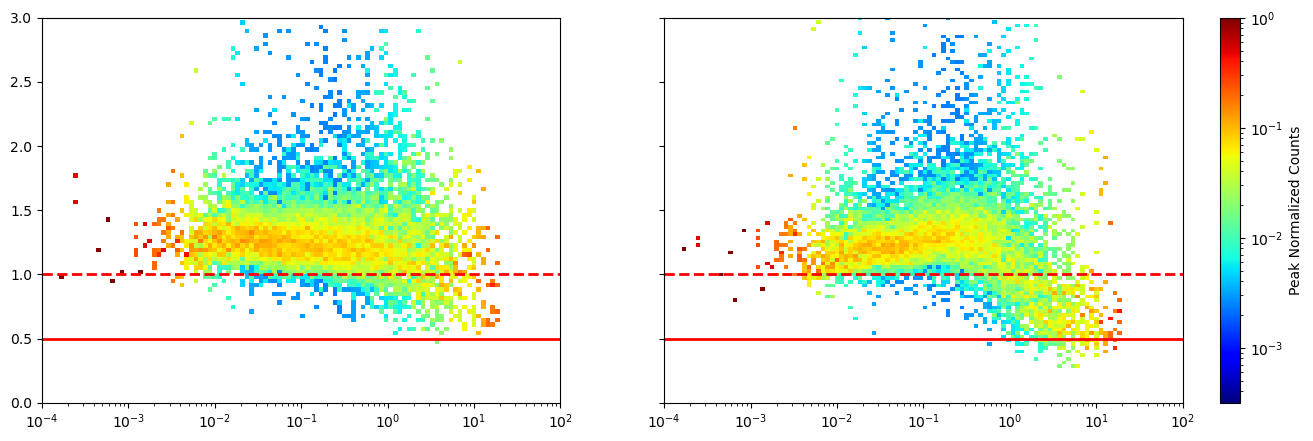

In [10]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(16, 5))

qm = scf.plot_tools.plot_hist2d(
    axes=ax[0], 
    x=AcHe2, 
    y=df_matched['vthHe2'] / df_matched['vthpr'], 
    scales=['log', 'linear'], 
    bins=[100, 200],
    norm_type='sum', 
    color_norm_type='log', 
    color_norm_range=[10**-3.5, 1], 
    separate='x',
    plot_kwargs={
        'cmap': 'jet',
    },
    mid_err_line='x',
    mid_method='median', 
    err_method='iqr',
    mid_err_line_kwargs={
        'color': 'black',
        'linewidth': 2,
    }
)

qm = scf.plot_tools.plot_hist2d(
    axes=ax[1], 
    x=AcHe2, 
    y=df_matched['vthO6'] / df_matched['vthpr'], 
    scales=['log', 'linear'], 
    bins=[100, 200],
    norm_type='sum', 
    color_norm_type='log', 
    color_norm_range=[10**-3.5, 1], 
    separate='x',
    plot_kwargs={
        'cmap': 'jet',
    },
    mid_err_line='x',
    mid_method='median', 
    err_method='iqr',
    mid_err_line_kwargs={
        'color': 'black',
        'linewidth': 2,
    }
)

ax[0].axhline(1, color='red', linestyle='--', linewidth=2)
ax[0].axhline(0.5, color='red', linestyle='-', linewidth=2)
ax[1].axhline(1, color='red', linestyle='--', linewidth=2)
ax[1].axhline(0.5, color='red', linestyle='-', linewidth=2)

ax[0].set_xlim(1e-4, 1e2)
ax[0].set_ylim(0, 3)

plt.colorbar(qm, ax=ax, orientation='vertical', fraction=0.05, pad=0.03, aspect=18.67).set_label('Peak Normalized Counts')

Hellinger, P. (2016). ION COLLISIONAL TRANSPORT COEFFICIENTS IN THE SOLAR WIND AT 1 au. The Astrophysical Journal, 825(2), 120. https://doi.org/10.3847/0004-637X/825/2/120

In [1]:
from datetime import datetime
from cdasws import CdasWs
cdas = CdasWs()

http_status, swe_data_xarray = cdas.get_data(
    dataset='WI_H1_SWE',
    variables=[
        'Proton_V_nonlin', 'Proton_Np_nonlin', 'Proton_Wpar_nonlin', 'Proton_Wperp_nonlin', 'Proton_VX_nonlin', 'Proton_VY_nonlin', 'Proton_VZ_nonlin',
        'Alpha_Na_nonlin', 'Alpha_Wpar_nonlin', 'Alpha_Wperp_nonlin', 'Alpha_VX_nonlin', 'Alpha_VY_nonlin', 'Alpha_VZ_nonlin',
        'BX', 'BY', 'BZ'
    ],
    time0=datetime(2024, 1, 1),
    time1=datetime(2024, 12, 1),
)

In [ ]:
swe_data = swe_data_xarray.to_dataframe().to_csv('../temp_file/swe_data.csv', index=True)

In [2]:
import pandas as pd
import numpy as np
import spcphys_common_functions as scf
import astropy.units as u
from astropy.constants import e
from scipy.constants import physical_constants
from matplotlib import pyplot as plt

swe_data = pd.read_csv('../temp_file/swe_data.csv', parse_dates=['Epoch'])

test_vp = swe_data['Proton_V_nonlin'].values
test_Bvec = np.concatenate([swe_data['BX'].values[:, np.newaxis], swe_data['BY'].values[:, np.newaxis], swe_data['BZ'].values[:, np.newaxis]], axis=1)
test_np = swe_data['Proton_Np_nonlin'].values
test_Tp_para = scf.vth_E_T.vth_to_E(swe_data['Proton_Wpar_nonlin'].values * u.km/u.s, n=1).to(u.eV).value
test_Tp_perp = scf.vth_E_T.vth_to_E(swe_data['Proton_Wperp_nonlin'].values * u.km/u.s, n=1).to(u.eV).value
test_vp_drift = np.einsum(
    'ij,ij->i', 
    np.concatenate([swe_data['Proton_VX_nonlin'].values[:, np.newaxis], swe_data['Proton_VY_nonlin'].values[:, np.newaxis], swe_data['Proton_VZ_nonlin'].values[:, np.newaxis]], axis=1), 
    test_Bvec / np.linalg.norm(test_Bvec, axis=1, keepdims=True)
)

test_na = swe_data['Alpha_Na_nonlin'].values
test_Ta_para = scf.vth_E_T.vth_to_E(swe_data['Alpha_Wpar_nonlin'].values * u.km/u.s, mass=physical_constants['alpha particle mass'][0] * u.kg, n=1).to(u.eV).value
test_Ta_perp = scf.vth_E_T.vth_to_E(swe_data['Alpha_Wperp_nonlin'].values * u.km/u.s, mass=physical_constants['alpha particle mass'][0] * u.kg, n=1).to(u.eV).value
test_va_drift = np.einsum(
    'ij,ij->i', 
    np.concatenate([swe_data['Alpha_VX_nonlin'].values[:, np.newaxis], swe_data['Alpha_VY_nonlin'].values[:, np.newaxis], swe_data['Alpha_VZ_nonlin'].values[:, np.newaxis]], axis=1), 
    test_Bvec / np.linalg.norm(test_Bvec, axis=1, keepdims=True)
)
te = (1*u.au / (test_vp * u.km / u.s)).si

In [ ]:
species_p = scf.coulomb_collision.SpeciesParamsComp(
    charge=1*e.si,
    mass=physical_constants['proton mass'][0] * u.kg,
    n=test_np * u.cm**-3,
    T_para=test_Tp_para * u.eV,
    T_perp=test_Tp_perp * u.eV,
    v_drift=test_vp_drift * u.km / u.s
)

# species_a = scf.coulomb_collision.SpeciesParamsComp(
species_a = dict(
    charge=2*e.si,
    mass=physical_constants['alpha particle mass'][0] * u.kg,
    n=test_na * u.cm**-3,
    T_para=test_Ta_para * u.eV,
    T_perp=test_Ta_perp * u.eV,
    v_drift=test_va_drift * u.km / u.s
)

In [4]:
F_abs_table_pa = scf.coulomb_collision.build_F_abc_lookup_table(
    species_s=species_p,
    species_t=species_a,
)

heating_dict_pa = scf.coulomb_collision.calc_heating_rates(
    species_s=species_p,
    other_species=[species_a],
    F_abc_lookup_table=F_abs_table_pa
)

/opt/miniconda3/envs/spcphys-notorch/lib/python3.11/site-packages/spcphys_common_functions/parameters/coulomb_collision.py:672: RuntimeWarning: Some points violate |1-A_st|<1; corresponding values are set to NaN.
  warnings.warn(


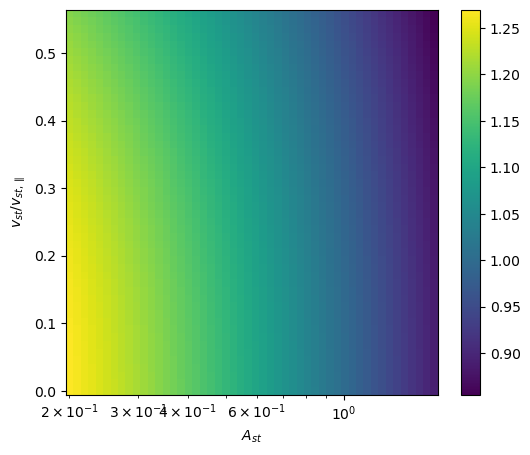

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

plt.pcolormesh(
    10**F_abs_table_pa['F_1_05_25'].grid[0], 
    F_abs_table_pa['F_1_05_25'].grid[1], 
    F_abs_table_pa['F_1_05_25'].values.T,
    cmap='viridis',
)
ax.set_xscale('log')
ax.set_xlabel(r'$A_{st}$')
ax.set_ylabel(r'$v_{st}/v_{st,\parallel}$')
plt.colorbar()

(-0.1, 0.3)

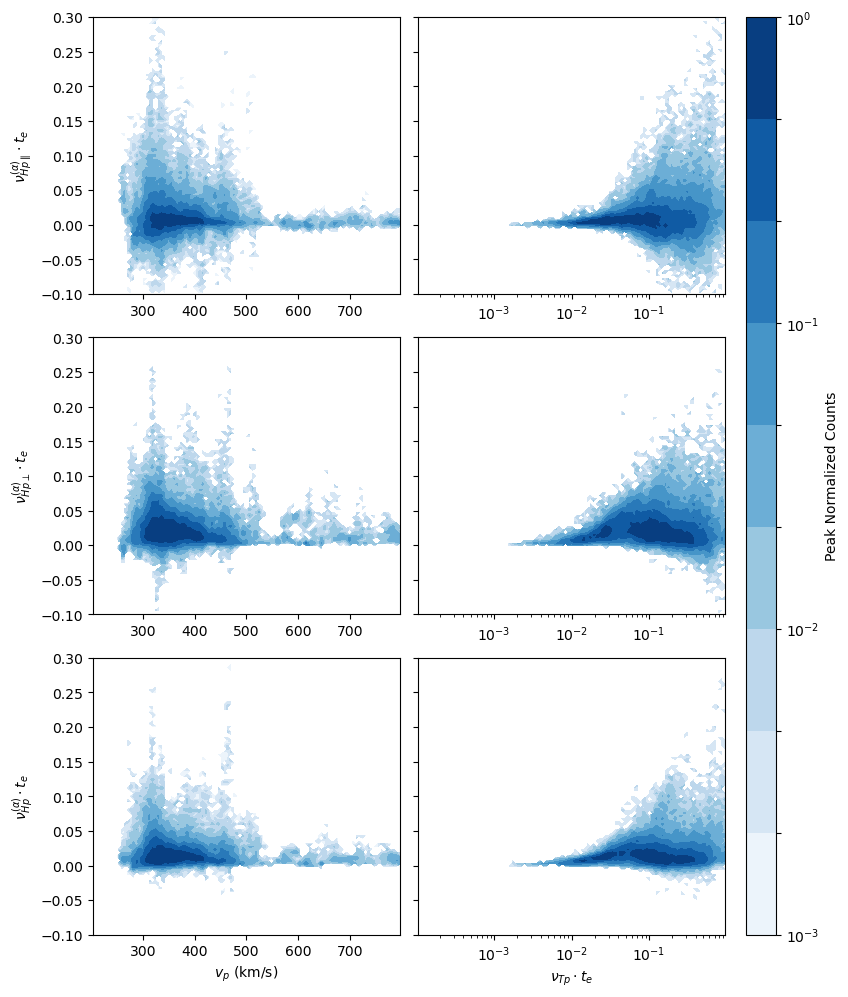

In [9]:
fig, ax = plt.subplots(3, 2, figsize=(8, 10), sharey=True)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[0, 0],
    x=test_vp,
    y=heating_dict_pa['nu_Hs_para'] * te,
    scales=['linear', 'linear'],
    bins=[np.linspace(200, 800, 100), np.linspace(-0.1, 0.3, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[0, 1],
    x=heating_dict_pa['nu_Ts'] * te,
    y=heating_dict_pa['nu_Hs_para'] * te,
    scales=['log', 'linear'],
    bins=[np.logspace(-4, 0, 100), np.linspace(-0.1, 0.3, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[1, 0],
    x=test_vp,
    y=heating_dict_pa['nu_Hs_perp'] * te,
    scales=['linear', 'linear'],
    bins=[np.linspace(200, 800, 100), np.linspace(-0.1, 0.3, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[1, 1],
    x=heating_dict_pa['nu_Ts'] * te,
    y=heating_dict_pa['nu_Hs_perp'] * te,
    scales=['log', 'linear'],
    bins=[np.logspace(-4, 0, 100), np.linspace(-0.1, 0.3, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)


quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[2, 0],
    x=test_vp,
    y=heating_dict_pa['nu_Hs'] * te,
    scales=['linear', 'linear'],
    bins=[np.linspace(200, 800, 100), np.linspace(-0.1, 0.3, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[2, 1],
    x=heating_dict_pa['nu_Ts'] * te,
    y=heating_dict_pa['nu_Hs'] * te,
    scales=['log', 'linear'],
    bins=[np.logspace(-4, 0, 100), np.linspace(-0.1, 0.3, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

ax[0, 0].set_ylabel(r'$\nu_{Hp\parallel}^{(\alpha)} \cdot t_e$')
ax[1, 0].set_ylabel(r'$\nu_{Hp\perp}^{(\alpha)} \cdot t_e$')
ax[2, 0].set_ylabel(r'$\nu_{Hp}^{(\alpha)} \cdot t_e$')
ax[2, 0].set_xlabel(r'$v_p$ (km/s)')
ax[2, 1].set_xlabel(r'$\nu_{Tp} \cdot t_e$')
plt.tight_layout()

plt.colorbar(quadmesh, ax=ax, orientation='vertical', fraction=0.05, pad=0.03, aspect=30).set_label('Peak Normalized Counts')

ax[2, 0].set_ylim(-0.1, 0.3)

In [6]:
F_abs_table_ap = scf.coulomb_collision.build_F_abc_lookup_table(
    species_s=species_a,
    species_t=species_p,
)

heating_dict_ap = scf.coulomb_collision.calc_heating_rates(
    species_s=species_a,
    other_species=[species_p],
    F_abc_lookup_table=F_abs_table_ap
)

(-6.0, 2.0)

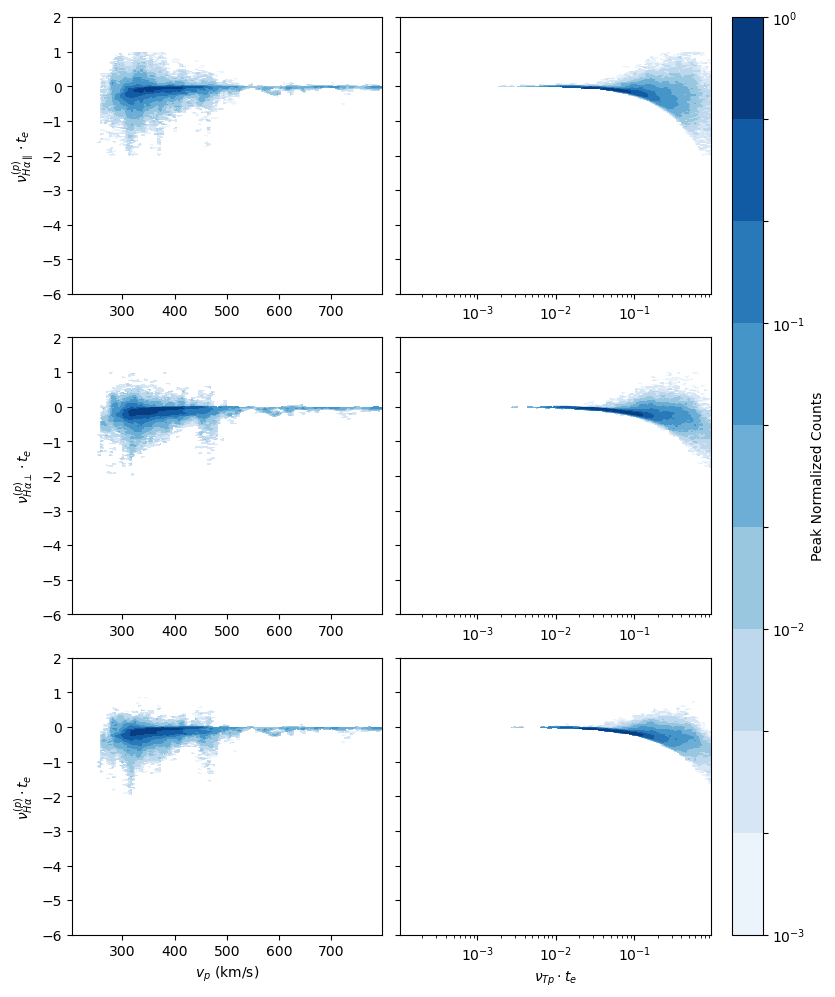

In [10]:
fig, ax = plt.subplots(3, 2, figsize=(8, 10), sharey=True)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[0, 0],
    x=test_vp,
    y=heating_dict_ap['nu_Hs_para'] * te,
    scales=['linear', 'linear'],
    bins=[np.linspace(200, 800, 100), np.linspace(-2, 1, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[0, 1],
    x=heating_dict_pa['nu_Ts'] * te,
    y=heating_dict_ap['nu_Hs_para'] * te,
    scales=['log', 'linear'],
    bins=[np.logspace(-4, 0, 100), np.linspace(-2, 1, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[1, 0],
    x=test_vp,
    y=heating_dict_ap['nu_Hs_perp'] * te,
    scales=['linear', 'linear'],
    bins=[np.linspace(200, 800, 100), np.linspace(-2, 1, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[1, 1],
    x=heating_dict_pa['nu_Ts'] * te,
    y=heating_dict_ap['nu_Hs_perp'] * te,
    scales=['log', 'linear'],
    bins=[np.logspace(-4, 0, 100), np.linspace(-2, 1, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)


quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[2, 0],
    x=test_vp,
    y=heating_dict_ap['nu_Hs'] * te,
    scales=['linear', 'linear'],
    bins=[np.linspace(200, 800, 100), np.linspace(-2, 1, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

quadmesh = scf.plot_tools.plot_hist2d(
    axes=ax[2, 1],
    x=heating_dict_pa['nu_Ts'] * te,
    y=heating_dict_ap['nu_Hs'] * te,
    scales=['log', 'linear'],
    bins=[np.logspace(-4, 0, 100), np.linspace(-2, 1, 100)],
    norm_type='max',
    color_norm_type='log',
    color_norm_range=[1e-3, 1],
    plot_method='contourf',
    plot_kwargs={
        'cmap': 'Blues',
        'levels': np.logspace(-3, 0, 10)
    }
)

ax[0, 0].set_ylabel(r'$\nu_{H\alpha\parallel}^{(p)} \cdot t_e$')
ax[1, 0].set_ylabel(r'$\nu_{H\alpha\perp}^{(p)} \cdot t_e$')
ax[2, 0].set_ylabel(r'$\nu_{H\alpha}^{(p)} \cdot t_e$')
ax[2, 0].set_xlabel(r'$v_p$ (km/s)')
ax[2, 1].set_xlabel(r'$\nu_{Tp} \cdot t_e$')
plt.tight_layout()

plt.colorbar(quadmesh, ax=ax, orientation='vertical', fraction=0.05, pad=0.03, aspect=30).set_label('Peak Normalized Counts')

ax[2, 0].set_ylim(-6, 2)